In [2]:
library(openxlsx)
library(dplyr)
library(ggplot2)
library(robvis)
library(metafor)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loading required package: metadat


Loading the 'metafor' package (version 3.8-1). For an
introduction to the package please type: help(metafor)




In [3]:
Dataset <- read.xlsx('../../Dataset final (RoB mod).xlsx', 'Combined')
# colnames(Dataset)
Dataset <- Dataset[c('Study.Identifier', 'Caregiver.intervention.type','Caregiver.intervention.subgroups','Effect.measure','Measurement.method','Measurement.type','Pre_mean','Pre_N','Pre_SD','Post_mean','Post_N','Post_SD','Duration', 'Measurement.points.(days.from.start)', 'Treatment.duration.(days.from.start)')]
data_cols <- c("Pre_mean","Pre_N","Pre_SD","Post_mean","Post_N","Post_SD")
info_cols <- colnames(Dataset)[-which(colnames(Dataset) %in% data_cols)]
meta_df.ctrl <- Dataset[Dataset$Caregiver.intervention.type == 'No intervention', ]
meta_df.expt <- Dataset[Dataset$Caregiver.intervention.type != 'No intervention',]

meta_df.es <- list()
for (i in 1:nrow(meta_df.expt)){
    item <- meta_df.expt[i, ]
    item_info <- item[info_cols]
    item_data <- item[data_cols]
    colnames(item_data) <- c("Expt_Pre_mean","Expt_Pre_N","Expt_Pre_SD","Expt_Post_mean","Expt_Post_N","Expt_Post_SD")
    item_data_ctrl <- meta_df.ctrl[meta_df.ctrl$Study.Identifier == item_info$Study.Identifier, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$Effect.measure	== item_info$Effect.measure, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$Measurement.method	== item_info$Measurement.method, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$Measurement.type	== item_info$Measurement.type, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$Duration	== item_info$Duration, ]
    item_data_ctrl <- item_data_ctrl[item_data_ctrl$"Measurement.points.(days.from.start)"	== item_info$"Measurement.points.(days.from.start)", ]
    item_data_ctrl <- item_data_ctrl[data_cols]
    colnames(item_data_ctrl) <- c("Ctrl_Pre_mean","Ctrl_Pre_N","Ctrl_Pre_SD","Ctrl_Post_mean","Ctrl_Post_N","Ctrl_Post_SD")
    data_item <- cbind(item_info, item_data, item_data_ctrl)
    meta_df.es  <- rbind(meta_df.es , data_item)
}

# multiplicity detection
temp_list <- list()
for (effect.measure in unique(meta_df.es$Effect.measure)){
    temp <- meta_df.es[meta_df.es$Effect.measure == effect.measure, ]
    temp_data <- data.frame(table(temp$Study.Identifier))
    temp_list <- c(temp_list, as.character(temp_data[which(temp_data$Freq > 1), ]$Var1))
}
unique(temp_list)

[[1]]
[1] "Mahdavi 2017"

[[2]]
[1] "Pahlavanzadeh 2010"

[[3]]
[1] "Shata 2017"

[[4]]
[1] "Wang 2014a"

[[5]]
[1] "Zarepour 2020"

[[6]]
[1] "Pan 2019"

[[7]]
[1] "Guerra 2011"

[[8]]
[1] "Orawan 2018"

In [4]:
# 'Mahdavi 2017' has two intervention groups, so there is no need to change.
# 'Pahlavanzadeh 2010' has two measurement points, we choose 35 days at the end of intervention
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Pahlavanzadeh 2010' & meta_df.es$'Measurement.points.(days.from.start)' == 65), ]
# 'Shata 2017' has two measurement points, we choose 56 days at the end of intervention
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Shata 2017' & meta_df.es$'Measurement.points.(days.from.start)' == 56), ]

# 'Wang 2014a' has two measurement points, we choose 365 days at the end of intervention
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Wang 2014a' & meta_df.es$'Measurement.points.(days.from.start)' == 180), ]

# 'Zarepour 2020' has two measurement points, we choose 58 days, one month after the end of intervention also the closest measurement point
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Zarepour 2020' & meta_df.es$'Measurement.points.(days.from.start)' == 118), ]

# 'Pan 2019' has two measurement points, we choose 150 days, one month after the end of intervention also the closest measurement point
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Pan 2019' & meta_df.es$'Measurement.points.(days.from.start)' == 210), ]

# 'Guerra 2011' has two measurement scales for caregiver neuropsychiatric symptoms, we choose NPI-Q severity as it is the most comparable to other included studies
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Guerra 2011' & meta_df.es$Measurement.method == 'SRQ-20'), ]

# 'Orawan 2018' has three measurement points, we choose 56 days, the closest measurement point to the end of intervention
meta_df.es <- meta_df.es[- which(meta_df.es$Study.Identifier == 'Orawan 2018' & meta_df.es$'Measurement.points.(days.from.start)' > 56), ]

# multiplicity detection again!
temp_list <- list()
for (effect.measure in unique(meta_df.es$Effect.measure)){
    temp <- meta_df.es[meta_df.es$Effect.measure == effect.measure, ]
    temp_data <- data.frame(table(temp$Study.Identifier))
    temp_list <- c(temp_list, as.character(temp_data[which(temp_data$Freq > 1), ]$Var1))
}
unique(temp_list)

[[1]]
[1] "Mahdavi 2017"

In [5]:
es.stats <- aggregate(meta_df.es[c('Expt_Post_N', 'Ctrl_Post_N')], list(meta_df.es$Effect.measure), FUN=sum, na.rm = TRUE)
es.stats.freq <- data.frame(table(meta_df.es$Effect.measure))
colnames(es.stats)[1] <- 'Effect.measure'
es.stats <- bind_cols(es.stats, 'Freq'=es.stats.freq$Freq)
es.stats$Sample_size <- es.stats$Expt_Post_N + es.stats$Ctrl_Post_N
es.stats

Effect.measure,Expt_Post_N,Ctrl_Post_N,Freq,Sample_size
<chr>,<dbl>,<dbl>,<int>,<dbl>
Caregiver anxiety,86,88,3,174
Caregiver burden,510,516,13,1026
Caregiver depression,115,108,4,223
Caregiver distress,53,57,2,110
Caregiver environmental quality of life,27,29,1,56
Caregiver mental health,50,51,2,101
Caregiver neuropsychiatric symptoms,27,29,1,56
Caregiver phychological quality of life,53,57,2,110
Caregiver physical quality of life,53,57,2,110


In [10]:
plot_funnel <- function(model){
    funnel(model)

    ### regression test (by default using the standard error as predictor)
    reg <- regtest(res)
    ### add regression line to funnel plot
    se <- seq(0,0.8,length=100)
    lines(coef(reg$fit)[1] + coef(reg$fit)[2]*se, se)

    ### regression test (using the sampling variance as predictor)
    reg <- regtest(res, predictor="vi")
    ### add regression line to funnel plot (using the sampling variance as predictor)
    lines(coef(reg$fit)[1] + coef(reg$fit)[2]*se^2, se, lwd=2, lty="dotted")

    ### add legend
    legend("topright", inset=.02, lty=c("solid","dotted"), lwd=2, cex=0.9, bg="white",
            legend=c("Standard Errors as Predictor",
                "Sampling Variances as Predictor"))
}

[1] "Caregiver burden"

Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = -0.1026, p = 0.6754



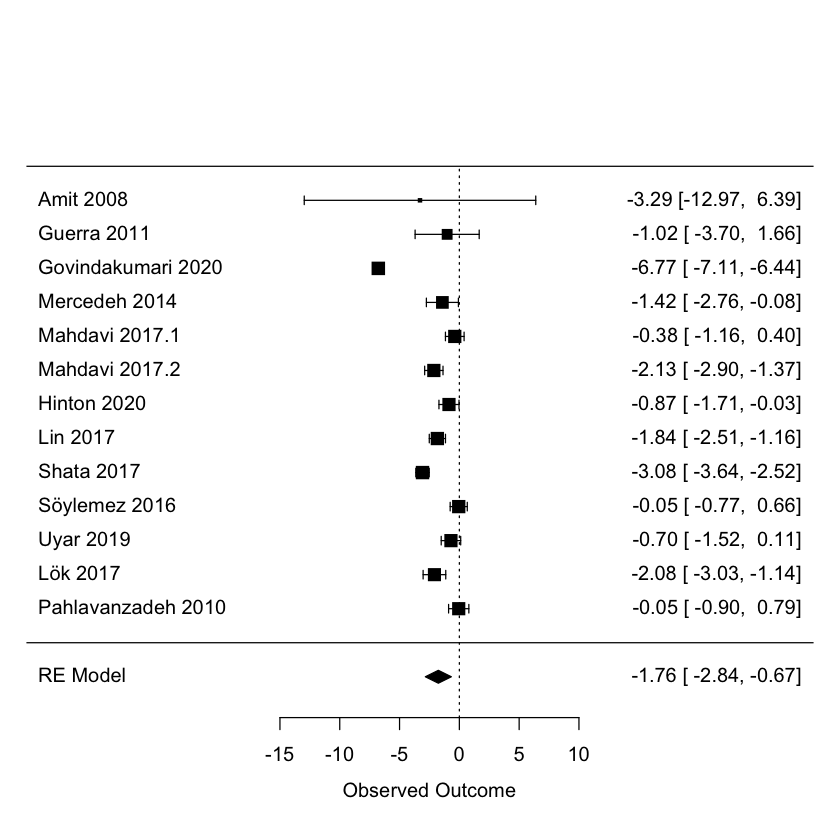

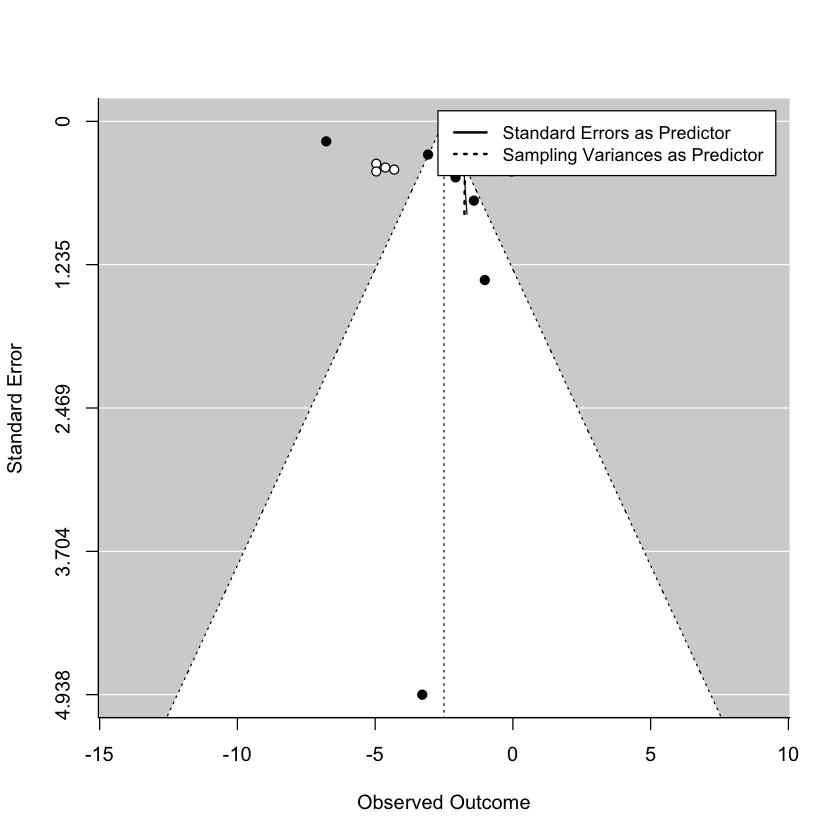

[1] "Caregiver depression"

Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = -0.6667, p = 0.3333



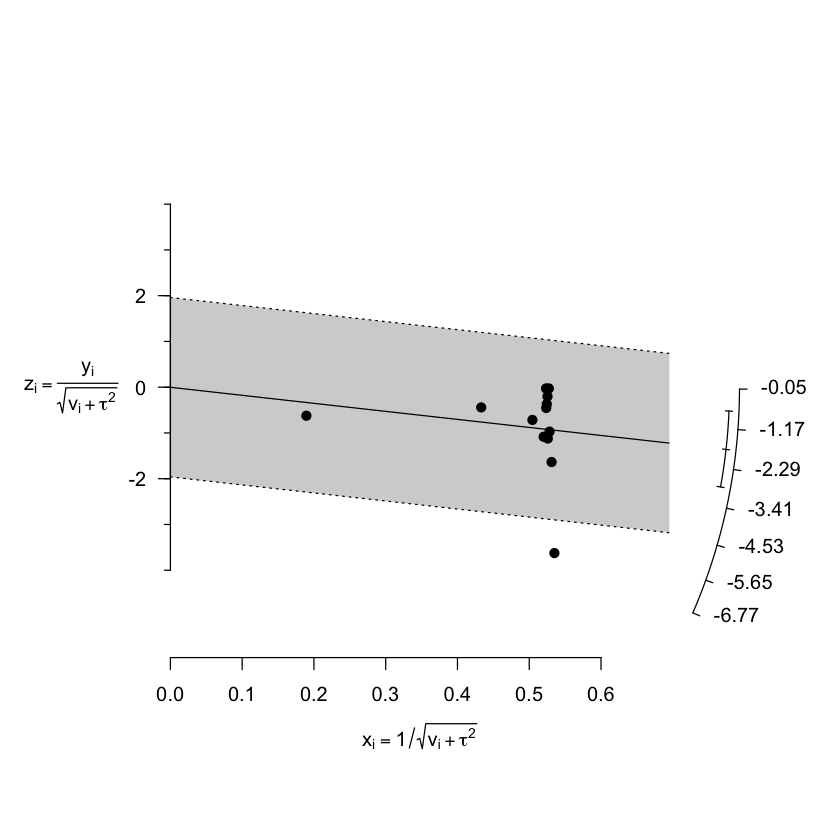

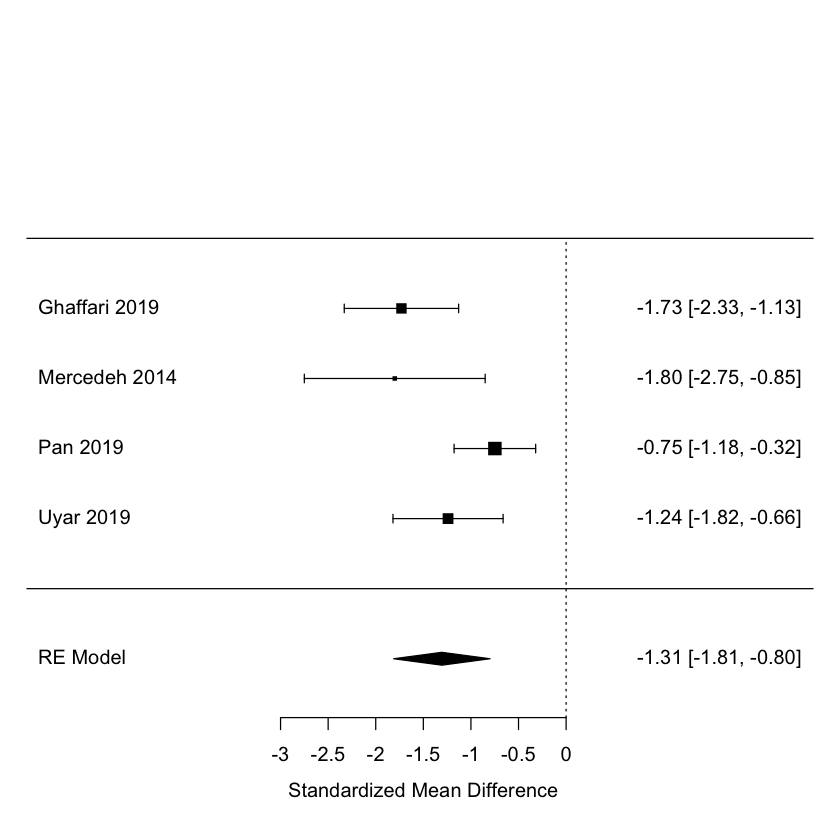

[1] "Caregiver quality of life"


Warning message in cor.test.default(yi.star, vi, method = "kendall", exact = exact):
“Cannot compute exact p-value with ties”


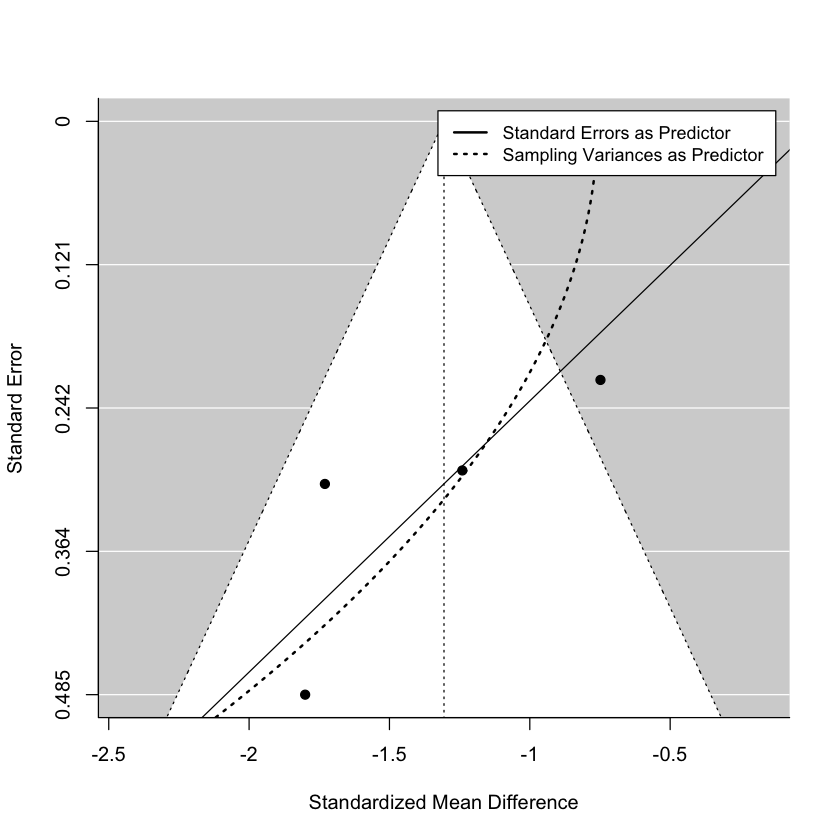


Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = -0.1380, p = 0.7021



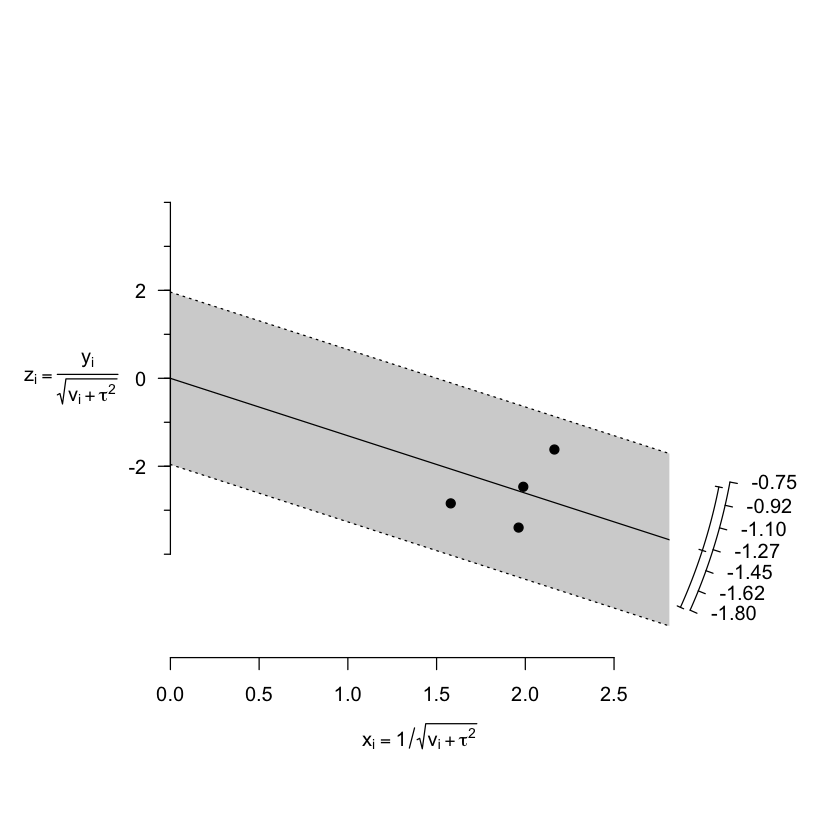

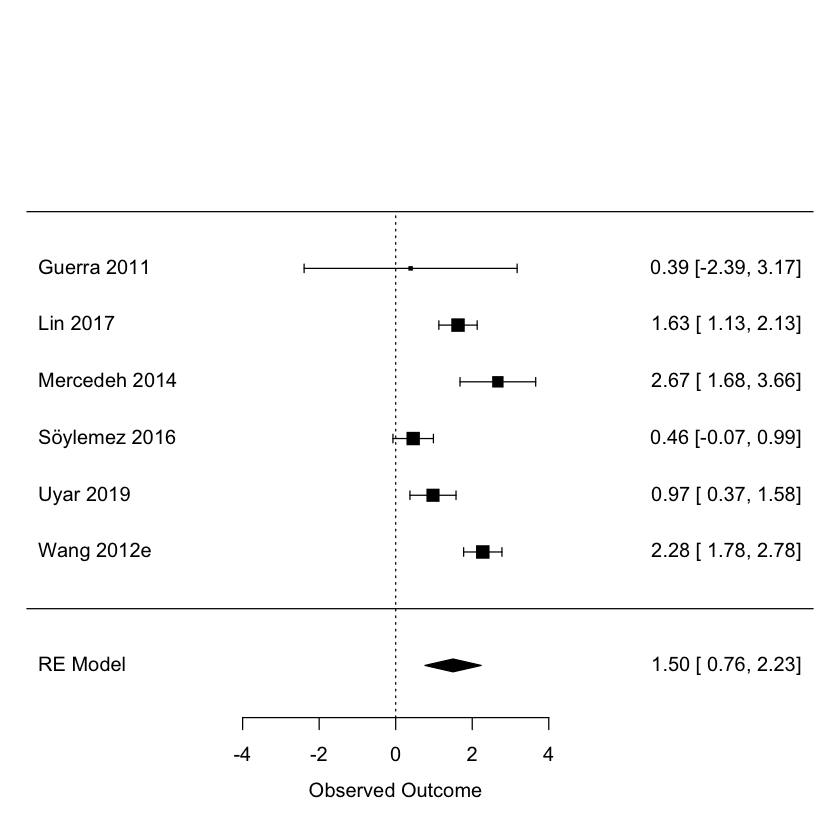

Warning message:
“Studies with NAs omitted from model fitting.”


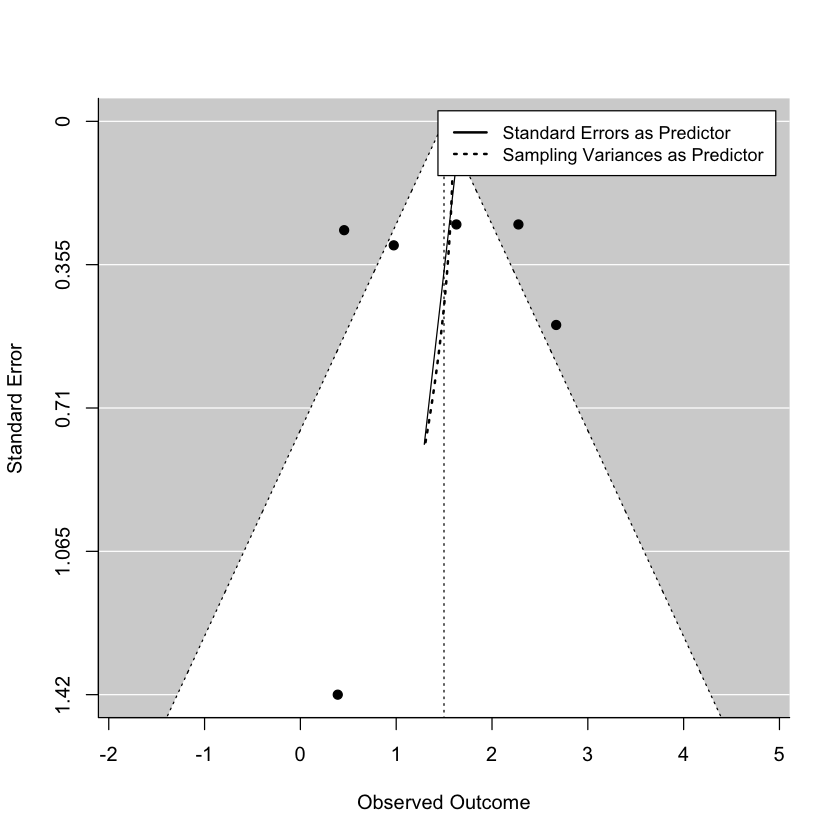

[1] "Patient cognitive function"

Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = -0.2000, p = 0.7194



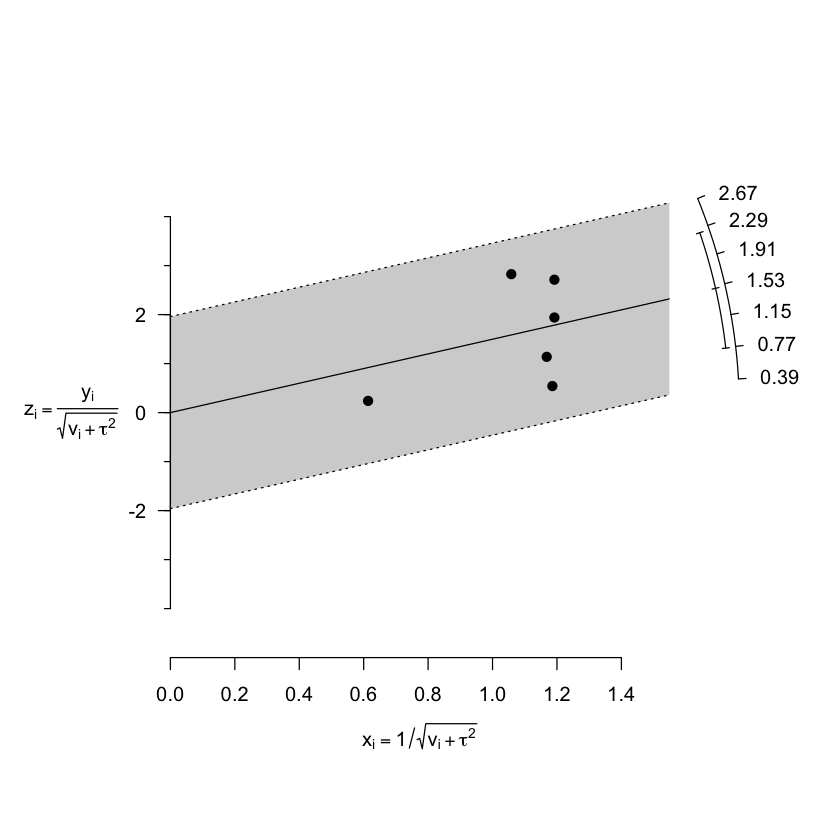

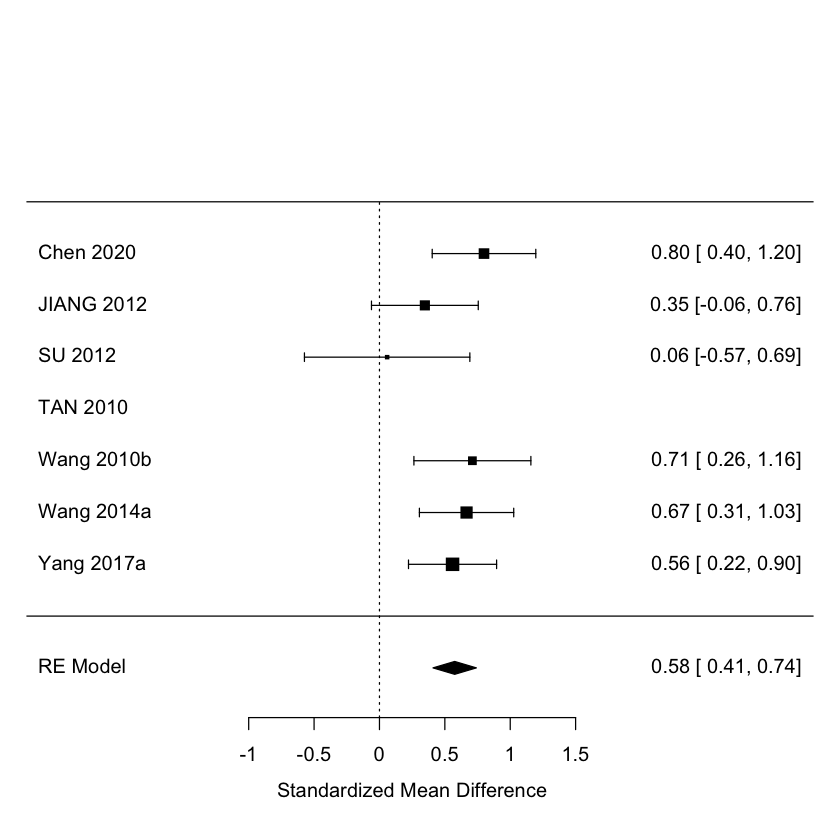

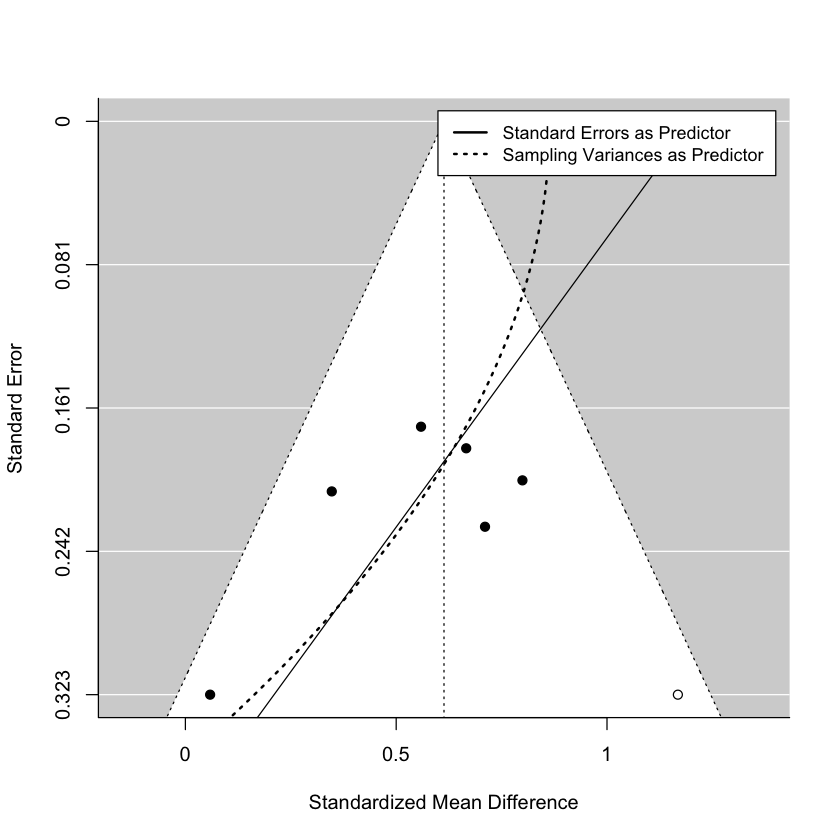

[1] "Patient quality of life"

Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = -0.2000, p = 0.8167



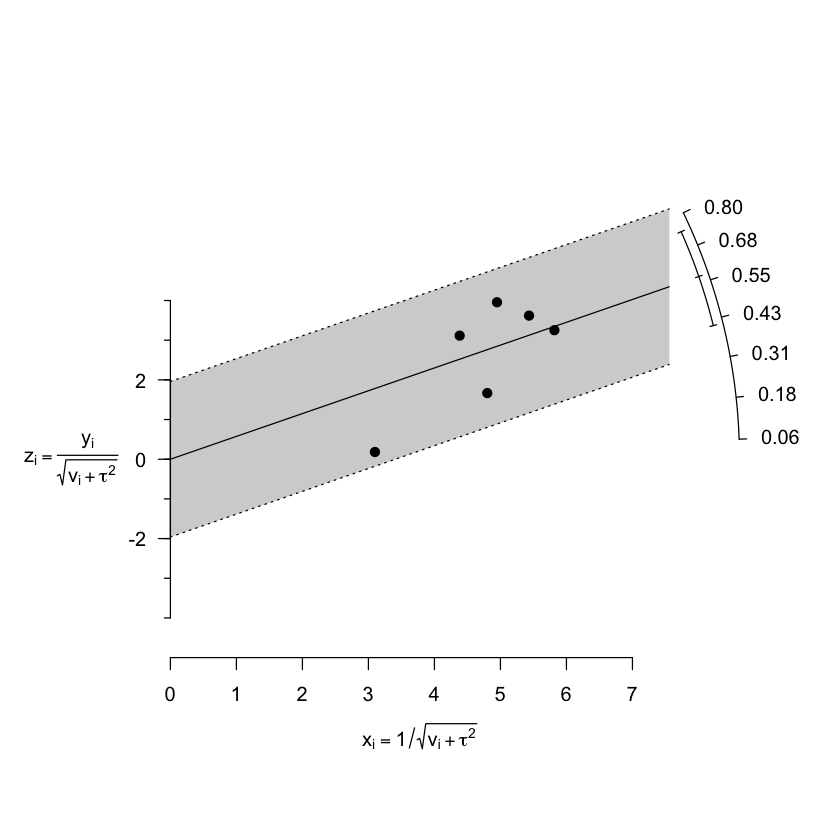

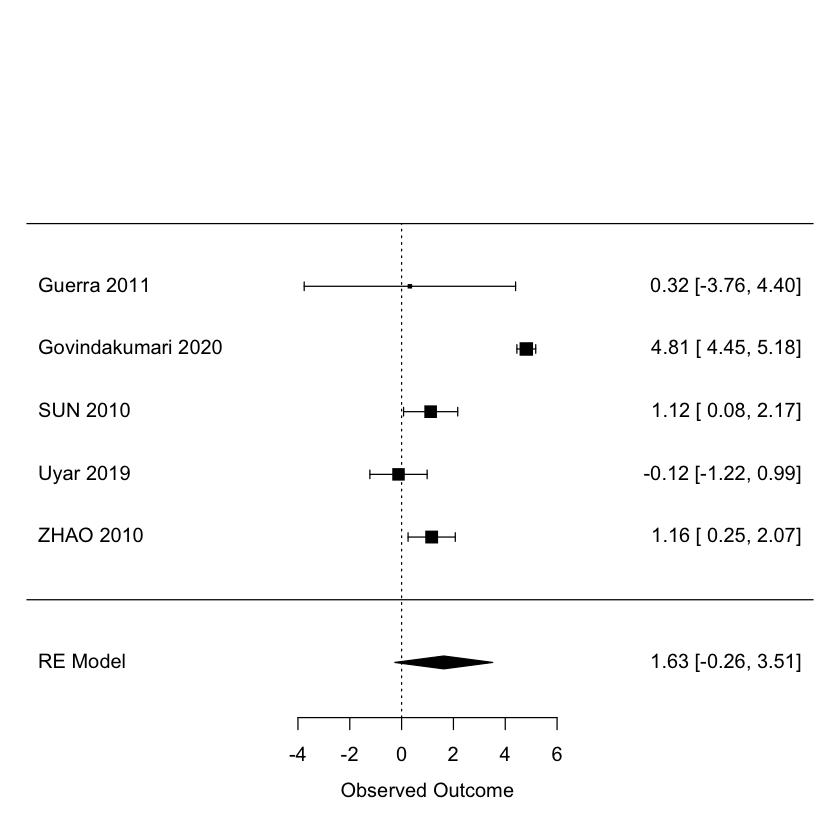

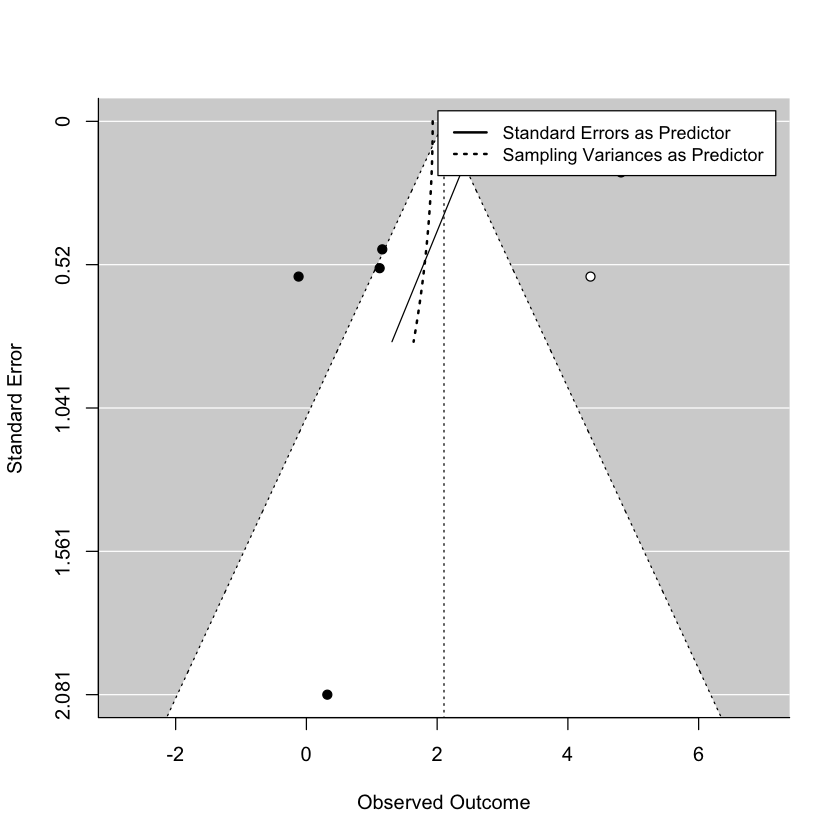

effect.measure,pred,se,ci.lb,ci.ub,pi.lb,pi.ub,I2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Caregiver burden,-1.7569514,0.55470387,-2.8441510,-0.6697518,-5.5629495,2.0490467,95.938260378
Caregiver depression,-1.3056723,0.25834828,-1.8120256,-0.7993189,-2.2507561,-0.3605884,64.219966685
Caregiver quality of life,1.4989168,0.37504791,0.7638364,2.2339972,-0.2311490,3.2289825,85.507598331
Patient cognitive function,0.5752688,0.08460377,0.4094484,0.7410891,0.4094199,0.7411177,0.005614801
Patient quality of life,1.6273959,0.96289761,-0.2598488,3.5146405,-2.7077789,5.9625706,94.883009272


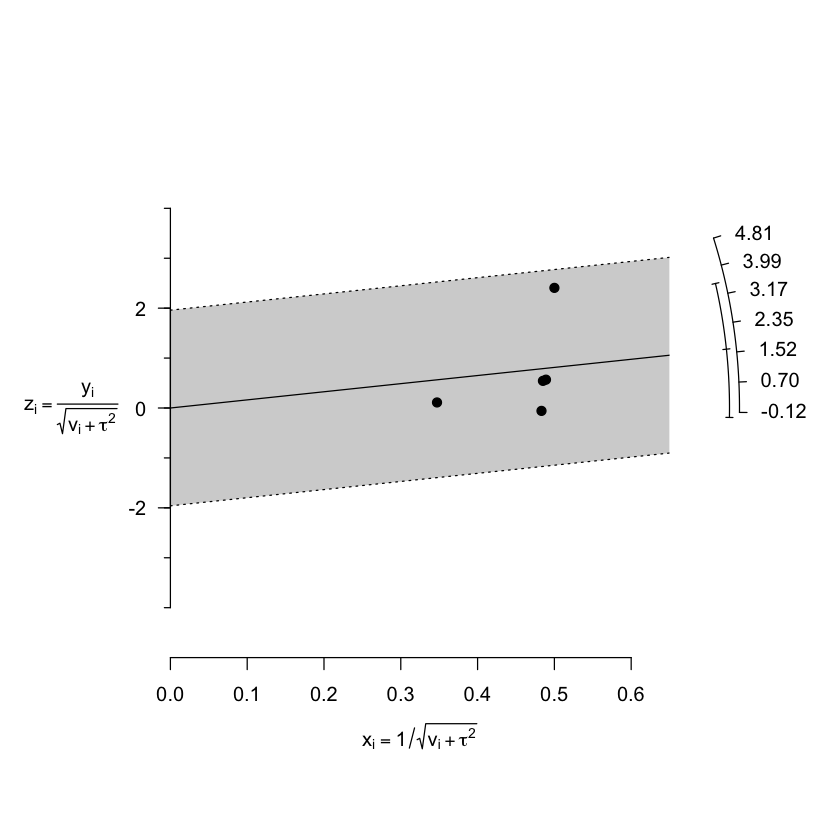

In [11]:
# One-click meta-anlaysis for all outcomes
es_df_set <- list()
res_predict <- list()
for (effect.measure in es.stats$Effect.measure ){
    es_df <- meta_df.es[meta_df.es$Effect.measure == effect.measure, ]
    if (nrow(es_df) < 4){
        next
    }
    es_df.raw <- es_df[es_df$Measurement.type == 'Raw',]
    es_df.smd <- es_df[es_df$Measurement.type == 'SMD',]
    es_df.smd$yi <- es_df.smd$Expt_Post_mean
    es_df.smd$vi <- es_df.smd$Expt_Post_SD
    es_df.transformed <- escalc(m1i=Expt_Post_mean, sd1i=Expt_Post_SD, n1i=Expt_Post_N, 
                                m2i=Ctrl_Post_mean, sd2i=Ctrl_Post_SD, n2i=Ctrl_Post_N,
                                measure="SMD", vtype="AV", data=es_df.raw, slab = Study.Identifier)
    colnames(es_df.transformed) <- colnames(es_df.smd)
    es_df.smd <- rbind(es_df.smd, es_df.transformed)
    res <- rma(yi, vi, data=es_df.smd, slab = Study.Identifier)
    res.predict <- data.frame(effect.measure = effect.measure, predict(res), I2 = res$I2)
    res_predict <- rbind(res_predict, res.predict)
    print(effect.measure)
    print(ranktest(res))
    forest(res)
    if (nrow(es_df.smd) > 2){
        taf <- trimfill(res)
        plot_funnel(taf)
    }else{
        funnel(res)
    }
    #forest(res)
    #funnel(res)
    #qqnorm(res)
    #baujat(res)
    radial(res)
    es_df_set <- c(es_df_set , list(es_df.smd))
}
res_predict

author,year,ai,n1i,ci,n2i,rb.a,rb.b,rb.c,rb.d,rb.e,rb.f,yi,vi
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>
Amore-Coffea,2000,2,31,10,34,?,?,?,?,-,+,-1.7986799,0.6761494
Deliciozza,2004,10,40,9,40,+,?,?,?,-,+,0.1381503,0.2767025
Kahve-Paradiso,2002,0,0,0,0,-,-,?,+,+,+,NA,NA
Mama-Kaffa,1999,12,53,9,61,-,-,?,-,-,+,0.5253537,0.2380655
Morrocona,1998,3,15,1,17,+,?,?,+,+,+,1.3862944,1.4791667
Norscafe,1998,19,68,9,64,?,?,+,?,-,-,0.8627273,0.2023327
Oohlahlazza,1998,4,35,2,37,+,+,+,+,+,+,0.8145080,0.8108295
Piazza-Allerta,2003,8,35,6,37,?,?,?,+,+,+,0.4258324,0.3609618


Warning message:
“Studies with NAs omitted from model fitting.”



Random-Effects Model (k = 7; tau^2 estimator: DL)

tau^2 (estimated amount of total heterogeneity): 0.2206 (SE = 0.3594)
tau (square root of estimated tau^2 value):      0.4697
I^2 (total heterogeneity / total variability):   36.12%
H^2 (total variability / sampling variability):  1.57

Test for Heterogeneity:
Q(df = 6) = 9.3921, p-val = 0.1527

Model Results:

estimate      se    zval    pval    ci.lb   ci.ub    
  0.3466  0.3022  1.1468  0.2514  -0.2458  0.9390    

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



 pred ci.lb ci.ub pi.lb pi.ub 
 1.41  0.78  2.56  0.47  4.23 


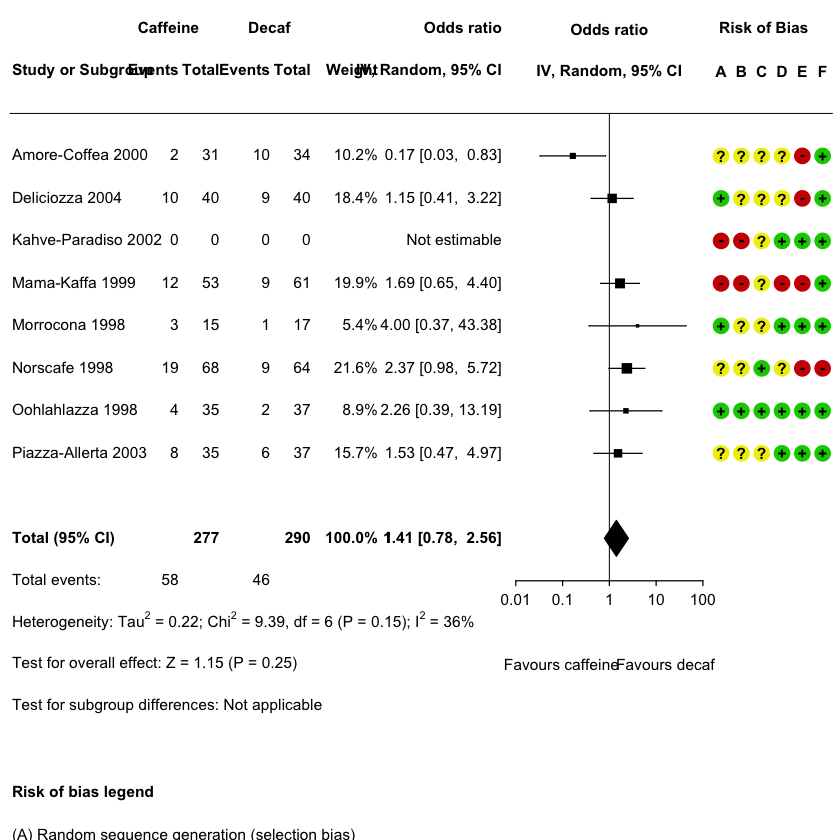

In [12]:
### create dataset
dat <- data.frame(author = c("Amore-Coffea", "Deliciozza", "Kahve-Paradiso", "Mama-Kaffa", "Morrocona", "Norscafe", "Oohlahlazza", "Piazza-Allerta"),
                  year   = c(2000, 2004, 2002, 1999, 1998, 1998, 1998, 2003),
                  ai     = c(2, 10, 0, 12, 3, 19, 4, 8),
                  n1i    = c(31, 40, 0, 53, 15, 68, 35, 35),
                  ci     = c(10, 9, 0, 9, 1, 9, 2, 6),
                  n2i    = c(34, 40, 0, 61, 17, 64, 37, 37),
                  rb.a   = c("?", "+", "-", "-", "+", "?", "+", "?"),
                  rb.b   = c("?", "?", "-", "-", "?", "?", "+", "?"),
                  rb.c   = c("?", "?", "?", "?", "?", "+", "+", "?"),
                  rb.d   = c("?", "?", "+", "-", "+", "?", "+", "+"),
                  rb.e   = c("-", "-", "+", "-", "+", "-", "+", "+"),
                  rb.f   = c("+", "+", "+", "+", "+", "-", "+", "+"))
 
### turn the risk of bias items into factors with levels +, -, and ?
dat[7:12] <- lapply(dat[7:12], factor, levels=c("+", "-", "?"))
 
### calculate log odds ratios and corresponding sampling variances (and use
### the 'slab' argument to store study labels as part of the data frame)
dat <- escalc(measure="OR", ai=ai, n1i=n1i, ci=ci, n2i=n2i, data=dat,
              slab=paste(author, year), drop00=TRUE)
dat
 
### note: using drop00=TRUE to leave the log odds ratio missing for the study
### with no events in either group (note the NAs for study 3)
 
### fit random-effects model (using DL estimator as RevMan does)
res <- rma(yi, vi, data=dat, method="DL")
res
 
### estimated average odds ratio (and 95% CI/PI)
pred <- predict(res, transf=exp, digits=2)
pred
 
############################################################################
 
### need the rounded estimate and CI bounds further below
pred <- formatC(c(pred$pred, pred$ci.lb, pred$ci.ub), format="f", digits=2)
 
### total number of studies
k <- nrow(dat)
 
### set na.action to "na.pass" (instead of the default, which is "na.omit"),
### so that even study 3 (with a missing log odds ratio) will be shown in the
### forest plot
options(na.action = "na.pass")
 
### get the weights and format them as will be used in the forest plot
weights <- paste0(formatC(weights(res), format="f", digits=1), "%")
weights[weights == "NA%"] <- ""
 
### adjust the margins
par(mar=c(10.8,0,1.3,1.3), mgp=c(3,0.2,0), tcl=-0.2)
 
### forest plot with extra annotations
sav <- forest(res, atransf=exp, at=log(c(.01, .10, 1, 10, 100)), xlim=c(-30,11),
       xlab="", efac=c(0,4), textpos=c(-30,-4.7), lty=c(1,1,0), refline=NA,
       ilab=cbind(ai, n1i, ci, n2i, weights),
       ilab.xpos=c(-20.6,-18.6,-16.1,-14.1,-10.8), ilab.pos=2,
       cex=0.78, header=c("Study or Subgroup","IV, Random, 95% CI"), mlab="")
 
### add horizontal line at the top
segments(sav$xlim[1]+0.5, k+1, sav$xlim[2], k+1, lwd=0.8)
 
### add vertical reference line at 0
segments(0, -2, 0, k+1, lwd=0.8)
 
### now we add a bunch of text; since some of the text falls outside of the
### plot region, we set xpd=NA so nothing gets clipped
par(xpd=NA)
 
### adjust cex as used in the forest plot and use a bold font
par(cex=sav$cex, font=2)
 
text(sav$ilab.xpos, k+2, pos=2, c("Events","Total","Events","Total","Weight"))
text(c(mean(sav$ilab.xpos[1:2]),mean(sav$ilab.xpos[3:4])), k+3, pos=2, c("Caffeine","Decaf"))
text(sav$textpos[2], k+3, "Odds ratio", pos=2)
text(0, k+3, "Odds ratio")
text(sav$xlim[2]-0.6, k+3, "Risk of Bias", pos=2)
text(0, k+2, "IV, Random, 95% CI")
text(c(sav$xlim[1],sav$ilab.xpos[c(2,4,5)]), -1, pos=c(4,2,2,2,2),
     c("Total (95% CI)", sum(dat$n1i), sum(dat$n2i), "100.0%"))
text(sav$xlim[1], -7, pos=4, "Risk of bias legend")
 
### first hide the non-bold summary estimate text and then add it back in bold font
rect(sav$textpos[2], -1.5, sav$ilab.xpos[5], -0.5, col="white", border=NA)
text(sav$textpos[2], -1, paste0(pred[1], " [", pred[2], ",  ", pred[3], "]"), pos=2)
 
### use a non-bold font for the rest of the text
par(cex=sav$cex, font=1)
 
### add 'Favours caffeine'/'Favours decaf' text below the x-axis
text(log(c(.01, 100)), -4, c("Favours caffeine","Favours decaf"), pos=c(4,2), offset=-0.5)
 
### add 'Not estimable' for study with missing log odds ratio
text(sav$textpos[2], k+1-which(is.na(dat$yi)), "Not estimable", pos=2)
 
### add text for total events
text(sav$xlim[1], -2, pos=4, "Total events:")
text(sav$ilab.xpos[c(1,3)], -2, c(sum(dat$ai),sum(dat$ci)), pos=2)
 
### add text with heterogeneity statistics
text(sav$xlim[1], -3, pos=4, bquote(paste("Heterogeneity: ", "Tau"^2, " = ",
     .(formatC(res$tau2, digits=2, format="f")), "; ", "Chi"^2, " = ",
     .(formatC(res$QE, digits=2, format="f")), ", df = ", .(res$k - res$p),
     " (P = ", .(formatC(res$QEp, digits=2, format="f")), "); ", I^2, " = ",
     .(formatC(res$I2, digits=0, format="f")), "%")))
 
### add text for test of overall effect
text(sav$xlim[1], -4, pos=4, bquote(paste("Test for overall effect: Z = ",
     .(formatC(res$zval, digits=2, format="f")),
     " (P = ", .(formatC(res$pval, digits=2, format="f")), ")")))
 
### add text for test of subgroup differences
text(sav$xlim[1], -5, pos=4, bquote(paste("Test for subgroup differences: Not applicable")))
 
### add risk of bias points and symbols
cols <- c("#00cc00", "#cc0000", "#eeee00")
syms <- levels(dat$rb.a)
pos  <- seq(sav$xlim[2]-5.5,sav$xlim[2]-0.5,length=6)
for (i in 1:6) {
   points(rep(pos[i],k), k:1, pch=19, col=cols[dat[[6+i]]], cex=2.2)
   text(pos[i], k:1, syms[dat[[6+i]]], font=2)
}
text(pos, k+2, c("A","B","C","D","E","F"), font=2)
 
### add risk of bias legend
text(sav$xlim[1], -8:-13, pos=4, c(
                           "(A) Random sequence generation (selection bias)",
                           "(B) Allocation concealment (selection bias)",
                           "(C) Blinding of participants and personnel (performance bias)",
                           "(D) Incomplete outcome data (attrition bias)",
                           "(E) Selective reporting (reporting bias)",
                           "(F) Other bias"))

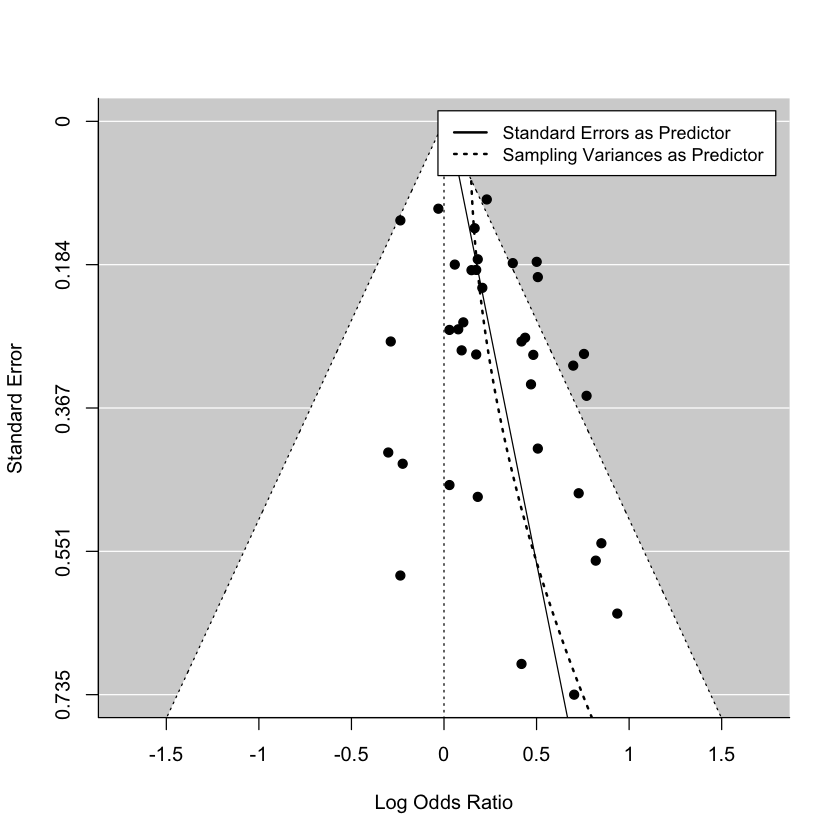

In [ ]:
### fit random-effects model
res <- rma(yi, vi, data=dat.hackshaw1998)
 
### funnel plot centered at 0
funnel(res, refline=0)
 
### regression test (by default using the standard error as predictor)
reg <- regtest(res)
 
### add regression line to funnel plot
se <- seq(0,0.8,length=100)
lines(coef(reg$fit)[1] + coef(reg$fit)[2]*se, se)
 
### regression test (using the sampling variance as predictor)
reg <- regtest(res, predictor="vi")
 
### add regression line to funnel plot (using the sampling variance as predictor)
lines(coef(reg$fit)[1] + coef(reg$fit)[2]*se^2, se, lwd=2, lty="dotted")
 
### add legend
legend("topright", inset=.02, lty=c("solid","dotted"), lwd=2, cex=0.9, bg="white",
       legend=c("Standard Errors as Predictor",
                "Sampling Variances as Predictor"))

In [268]:
table(meta_df.es$Effect.measure)


                      Caregiver anxiety                        Caregiver burden 
                                      3                                      13 
                   Caregiver depression                      Caregiver distress 
                                      4                                       2 
Caregiver environmental quality of life                 Caregiver mental health 
                                      1                                       2 
    Caregiver neuropsychiatric symptoms Caregiver phychological quality of life 
                                      1                                       2 
     Caregiver physical quality of life           Caregiver positive experience 
                                      2                                       1 
              Caregiver quality of life                 Caregiver self-efficacy 
                                      6                                       1 
         Caregiver subjecti

In [272]:
es_df.smd

,Study.Identifier,Caregiver.intervention.type,Caregiver.intervention.subgroups,Effect.measure,Measurement.method,Measurement.type,Duration,Measurement.points.(days.from.start),Treatment.duration.(days.from.start),Expt_Pre_mean,⋯,Expt_Post_N,Expt_Post_SD,Ctrl_Pre_mean,Ctrl_Pre_N,Ctrl_Pre_SD,Ctrl_Post_mean,Ctrl_Post_N,Ctrl_Post_SD,yi,vi
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
23,Guerra 2011,Multi-component intervention,"PEI, CBT",Caregiver distress,NPI-Q distress,SMD,6 months (5 weekly session intervention),180,35,NA,⋯,27,2.091099,NA,NA,NA,NA,29,NA,-0.0900000,2.09109912
100,Uyar 2019,Multi-component intervention,"PEI, GS",Caregiver distress,NPI-Q distress,Raw,16 weeks,112,112,11.87,⋯,26,8.700000,9.35,31,8.06,14.64,28,10.06,-0.4326261,0.07590884


In [271]:
es_df <- meta_df.es[meta_df.es$Effect.measure == 'Caregiver distress', ]

es_df.raw <- es_df[es_df$Measurement.type == 'Raw',]
es_df.smd <- es_df[es_df$Measurement.type == 'SMD',]
es_df.smd$yi <- es_df.smd$Expt_Post_mean
es_df.smd$vi <- es_df.smd$Expt_Post_SD
es_df.transformed <- escalc(m1i=Expt_Post_mean, sd1i=Expt_Post_SD, n1i=Expt_Post_N, 
                		 m2i=Ctrl_Post_mean, sd2i=Ctrl_Post_SD, n2i=Ctrl_Post_N,
                                measure="SMD", vtype="AV", data=es_df.raw, slab = Study.Identifier)
colnames(es_df.transformed) <- colnames(es_df.smd)
es_df.smd <- rbind(es_df.smd, es_df.transformed)
res <- rma(yi, vi, data=es_df.smd, slab = Study.Identifier)
res.predict <- data.frame(effect.measure = effect.measure, predict(res), I2 = res$I2)
res_predict <- rbind(res_predict, res.predict)
print(effect.measure)
print(res)
print(ranktest(res))

taf <- trimfill(res)
forest(res)
funnel(taf, legend=TRUE)
#forest(res)
#funnel(res)
#qqnorm(res)
#baujat(res)

es_df_set <- c(es_df_set , list(es_df.smd))

[1] "Caregiver distress"

Random-Effects Model (k = 2; tau^2 estimator: REML)

tau^2 (estimated amount of total heterogeneity): 0 (SE = 1.5323)
tau (square root of estimated tau^2 value):      0
I^2 (total heterogeneity / total variability):   0.00%
H^2 (total variability / sampling variability):  1.00

Test for Heterogeneity:
Q(df = 1) = 0.0542, p-val = 0.8160

Model Results:

estimate      se     zval    pval    ci.lb   ci.ub    
 -0.4206  0.2706  -1.5541  0.1202  -0.9511  0.1098    

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Rank Correlation Test for Funnel Plot Asymmetry

Kendall's tau = 1.0000, p = 1.0000



ERROR: Error in (function (yi, vi, sei, weights, ai, bi, ci, di, n1i, n2i, x1i, : Number of parameters to be estimated is larger than the number of observations.


# Plotting examples

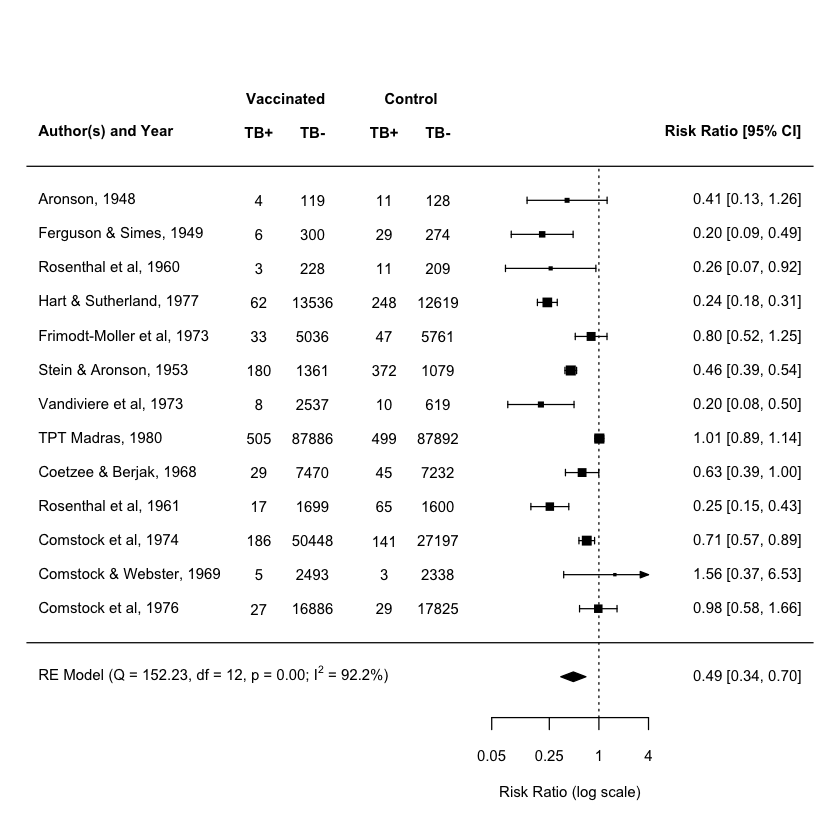

In [ ]:
### copy BCG vaccine meta-analysis data into 'dat'
dat <- dat.bcg
 
### calculate log risk ratios and corresponding sampling variances (and use
### the 'slab' argument to store study labels as part of the data frame)
dat <- escalc(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat,
              slab=paste(author, year, sep=", "))
 
### fit random-effects model
res <- rma(yi, vi, data=dat)
 
### forest plot with extra annotations
forest(res, atransf=exp, at=log(c(.05, .25, 1, 4)), xlim=c(-16,6),
       ilab=cbind(tpos, tneg, cpos, cneg), ilab.xpos=c(-9.5,-8,-6,-4.5),
       cex=.75, header="Author(s) and Year", mlab="")
op <- par(cex=.75, font=2)
text(c(-9.5,-8,-6,-4.5), res$k+2, c("TB+", "TB-", "TB+", "TB-"))
text(c(-8.75,-5.25),     res$k+3, c("Vaccinated", "Control"))
par(op)
 
### add text with Q-value, dfs, p-value, and I^2 statistic
text(-16, -1, pos=4, cex=0.75, bquote(paste("RE Model (Q = ",
     .(formatC(res$QE, digits=2, format="f")), ", df = ", .(res$k - res$p),
     ", p = ", .(formatC(res$QEp, digits=2, format="f")), "; ", I^2, " = ",
     .(formatC(res$I2, digits=1, format="f")), "%)")))

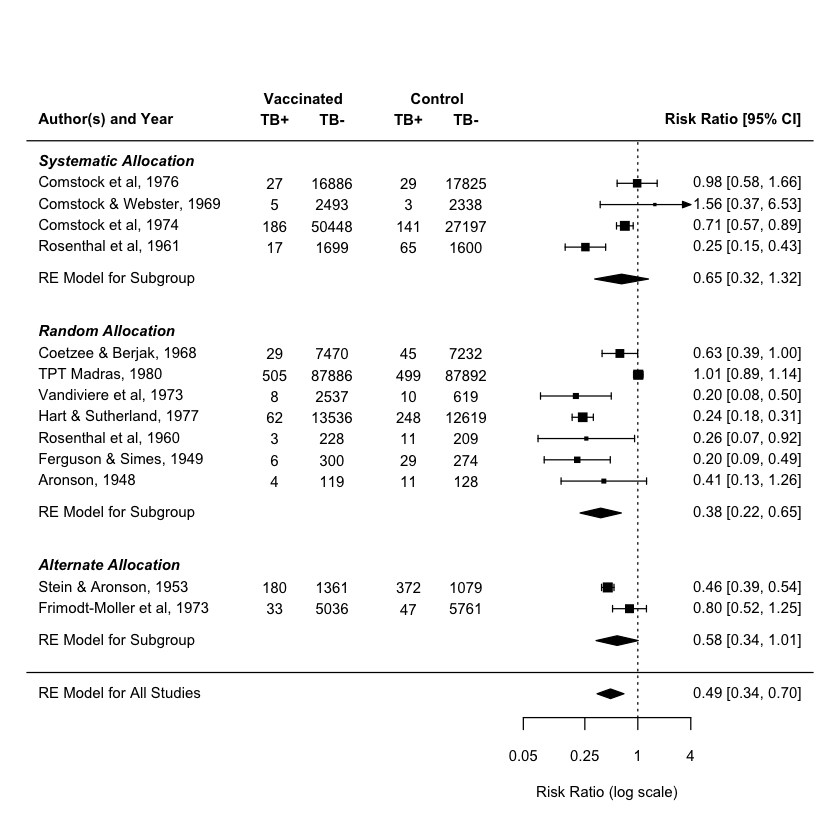

In [ ]:
res <- rma(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat.bcg,
           slab=paste(author, year, sep=", "))
tmp <- forest(res, xlim=c(-16, 4.6), at=log(c(.05, .25, 1, 4)), atransf=exp,
              ilab=cbind(tpos, tneg, cpos, cneg), ilab.xpos=c(-9.5,-8,-6,-4.5),
              cex=.75, ylim=c(-1, 27), order=alloc, rows=c(3:4,9:15,20:23),
              mlab="RE Model for All Studies", header="Author(s) and Year")
op <- par(cex=.75, font=2)
text(c(-9.5,-8,-6,-4.5), tmp$ylim[2]-1, c("TB+", "TB-", "TB+", "TB-"))
text(c(-8.75,-5.25),     tmp$ylim[2],   c("Vaccinated", "Control"))
par(font=4)
text(-16, c(24,16,5), c("Systematic Allocation", "Random Allocation",
                        "Alternate Allocation"), pos=4)
par(op)
res <- rma(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat.bcg,
           subset=(alloc=="systematic"))
addpoly(res, row=18.5, mlab="RE Model for Subgroup")
res <- rma(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat.bcg,
           subset=(alloc=="random"))
addpoly(res, row=7.5, mlab="RE Model for Subgroup")
res <- rma(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat.bcg,
           subset=(alloc=="alternate"))
addpoly(res, row=1.5, mlab="RE Model for Subgroup")

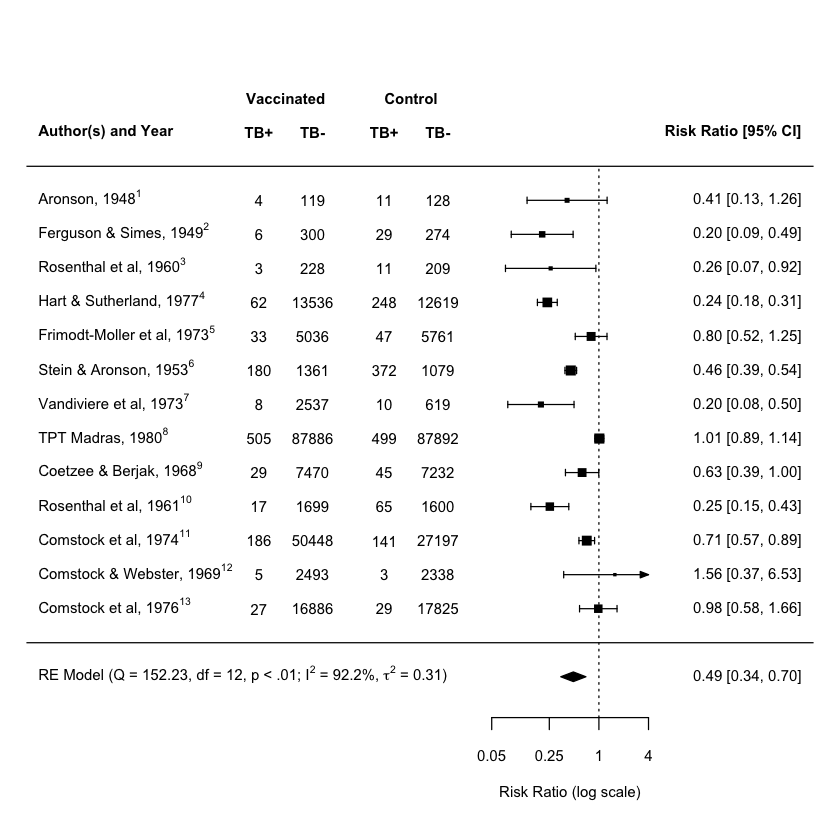

In [ ]:
### copy BCG vaccine meta-analysis data into 'dat'
dat <- dat.bcg
 
### calculate log risk ratios and corresponding sampling variances
dat <- escalc(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat)
 
### create study labels
dat$slab <- with(dat, paste(author, year, sep=", "))
 
### combine study labels with trial numbers in superscripts
dat$slab.ref <- mapply(function(x,y) as.expression(bquote(.(x)^.(y))), dat$slab, dat$trial)
 
### fit random-effects model
res <- rma(yi, vi, data=dat)
 
### a little helper function to add Q-test, I^2, and tau^2 estimate info
mlabfun <- function(text, x) {
   list(bquote(paste(.(text),
      " (Q = ", .(formatC(x$QE, digits=2, format="f")),
      ", df = ", .(x$k - x$p),
      ", p ", .(metafor:::.pval(x$QEp, digits=2, showeq=TRUE, sep=" ")), "; ",
      I^2, " = ", .(formatC(x$I2, digits=1, format="f")), "%, ",
      tau^2, " = ", .(formatC(x$tau2, digits=2, format="f")), ")")))}
 
### forest plot with extra annotations
forest(res, atransf=exp, at=log(c(.05, .25, 1, 4)), xlim=c(-16,6),
       ilab=cbind(tpos, tneg, cpos, cneg), ilab.xpos=c(-9.5,-8,-6,-4.5),
       cex=.75, header="Author(s) and Year", mlab=mlabfun("RE Model", res),
       slab=slab.ref)
op <- par(cex=.75, font=2)
text(c(-9.5,-8,-6,-4.5), res$k+2, c("TB+", "TB-", "TB+", "TB-"))
text(c(-8.75,-5.25),     res$k+3, c("Vaccinated", "Control"))
par(op)

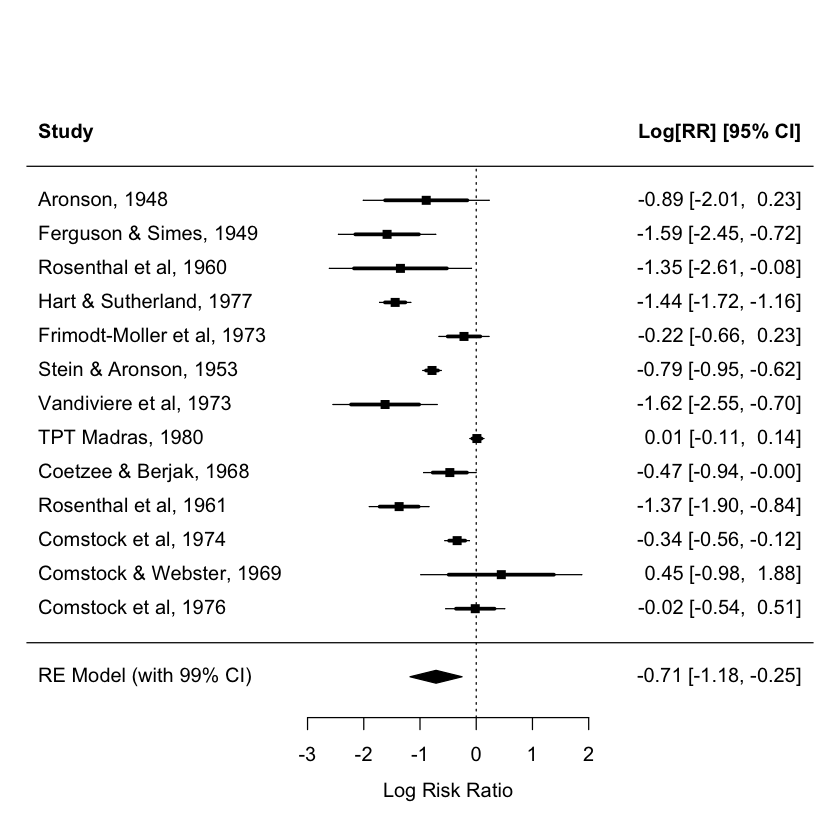

In [ ]:
library(metafor)
 
### copy BCG vaccine meta-analysis data into 'dat'
dat <- dat.bcg
 
### calculate log risk ratios and corresponding sampling variances
dat <- escalc(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat,
              slab=paste(author, year, sep=", "))
 
### draw forest plot with 95% CIs for the studies
with(dat, forest(yi, vi, xlim=c(-8,6), ylim=c(-1.5,nrow(dat)+3),
                 psize=1, efac=0, header=TRUE))
 
### superimpose forest plot with 80% CIs for the studies
par(new=TRUE)
with(dat, forest(yi, vi, xlim=c(-8,6), ylim=c(-1.5,nrow(dat)+3), level=80, lwd=3,
                 psize=NA, efac=NA, annotate=FALSE, refline=NA, slab=NA,
                 xaxt="n", xlab="", lty=c("solid","blank")))
 
### fit random-effects model
res <- rma(yi, vi, data=dat)
 
### add pooled estimate to the forest plot with a 99% CI
addpoly(res, row=-1, level=99, mlab="RE Model (with 99% CI)", annotate=TRUE)
 
### add a horizontal line between the studies and the pooled estimate
abline(h=0)

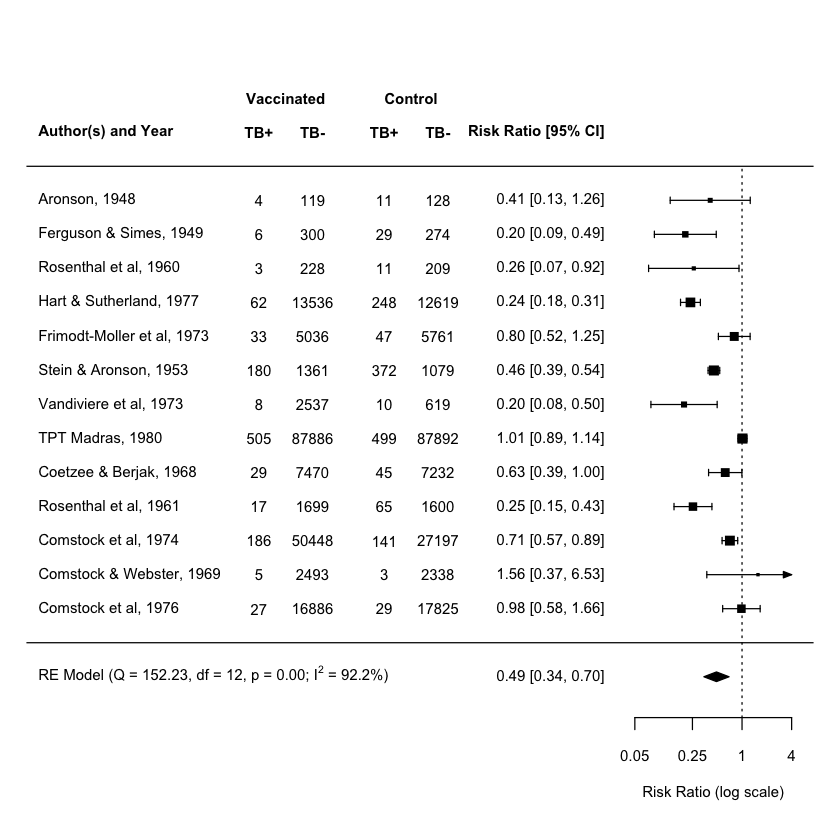

In [ ]:
### copy BCG vaccine meta-analysis data into 'dat'
dat <- dat.bcg
 
### calculate log risk ratios and corresponding sampling variances (and use
### the 'slab' argument to store study labels as part of the data frame)
dat <- escalc(measure="RR", ai=tpos, bi=tneg, ci=cpos, di=cneg, data=dat,
              slab=paste(author, year, sep=", "))
 
### fit random-effects model
res <- rma(yi, vi, data=dat)
 
### forest plot with extra annotations
forest(res, atransf=exp, at=log(c(.05, .25, 1, 4)), xlim=c(-20,2),
     ilab=cbind(tpos, tneg, cpos, cneg), ilab.xpos=c(-13.5,-12,-10,-8.5),
     cex=.75, header="Author(s) and Year", mlab="", textpos=c(-20,-3.5))
op <- par(cex=.75, font=2)
text(c(-13.5,-12,-10,-8.5), res$k+2, c("TB+", "TB-", "TB+", "TB-"))
text(c(-12.75,-9.25),       res$k+3, c("Vaccinated", "Control"))
par(op)
 
### add text with Q-value, dfs, p-value, and I^2 statistic
text(-20, -1, pos=4, cex=0.75, bquote(paste("RE Model (Q = ",
   .(formatC(res$QE, digits=2, format="f")), ", df = ", .(res$k - res$p),
   ", p = ", .(formatC(res$QEp, digits=2, format="f")), "; ", I^2, " = ",
   .(formatC(res$I2, digits=1, format="f")), "%)")))

author,year,ai,n1i,ci,n2i,rb.a,rb.b,rb.c,rb.d,rb.e,rb.f,yi,vi
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>
Amore-Coffea,2000,2,31,10,34,?,?,?,?,-,+,-1.7986799,0.6761494
Deliciozza,2004,10,40,9,40,+,?,?,?,-,+,0.1381503,0.2767025
Kahve-Paradiso,2002,0,0,0,0,-,-,?,+,+,+,NA,NA
Mama-Kaffa,1999,12,53,9,61,-,-,?,-,-,+,0.5253537,0.2380655
Morrocona,1998,3,15,1,17,+,?,?,+,+,+,1.3862944,1.4791667
Norscafe,1998,19,68,9,64,?,?,+,?,-,-,0.8627273,0.2023327
Oohlahlazza,1998,4,35,2,37,+,+,+,+,+,+,0.8145080,0.8108295
Piazza-Allerta,2003,8,35,6,37,?,?,?,+,+,+,0.4258324,0.3609618


Warning message:
“Studies with NAs omitted from model fitting.”



Random-Effects Model (k = 7; tau^2 estimator: DL)

tau^2 (estimated amount of total heterogeneity): 0.2206 (SE = 0.3594)
tau (square root of estimated tau^2 value):      0.4697
I^2 (total heterogeneity / total variability):   36.12%
H^2 (total variability / sampling variability):  1.57

Test for Heterogeneity:
Q(df = 6) = 9.3921, p-val = 0.1527

Model Results:

estimate      se    zval    pval    ci.lb   ci.ub    
  0.3466  0.3022  1.1468  0.2514  -0.2458  0.9390    

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



 pred ci.lb ci.ub pi.lb pi.ub 
 1.41  0.78  2.56  0.47  4.23 


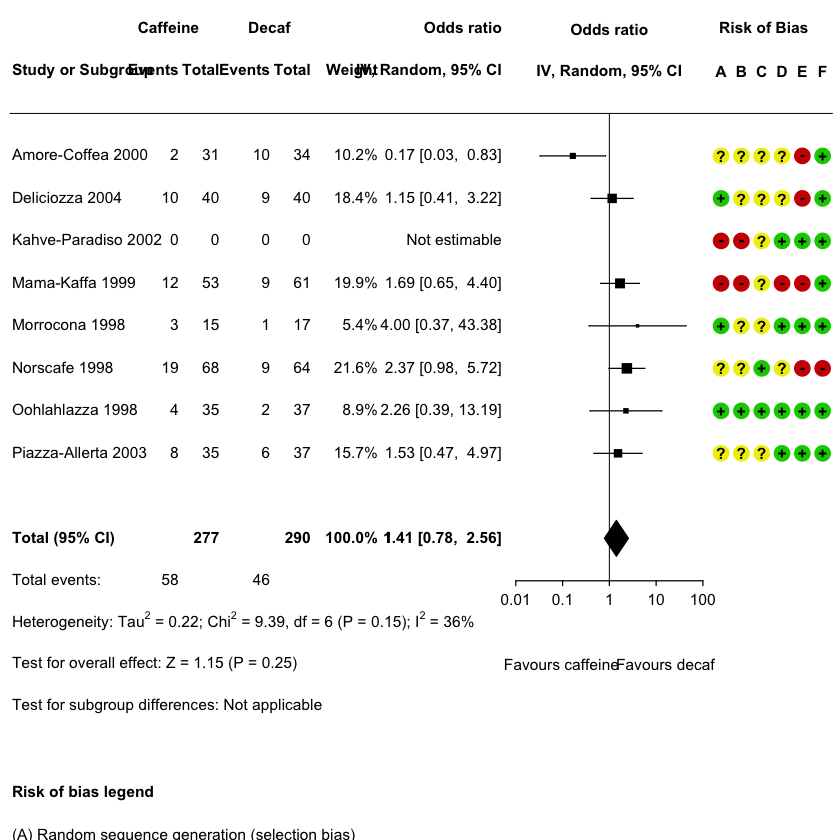

In [ ]:
### create dataset
dat <- data.frame(author = c("Amore-Coffea", "Deliciozza", "Kahve-Paradiso", "Mama-Kaffa", "Morrocona", "Norscafe", "Oohlahlazza", "Piazza-Allerta"),
                  year   = c(2000, 2004, 2002, 1999, 1998, 1998, 1998, 2003),
                  ai     = c(2, 10, 0, 12, 3, 19, 4, 8),
                  n1i    = c(31, 40, 0, 53, 15, 68, 35, 35),
                  ci     = c(10, 9, 0, 9, 1, 9, 2, 6),
                  n2i    = c(34, 40, 0, 61, 17, 64, 37, 37),
                  rb.a   = c("?", "+", "-", "-", "+", "?", "+", "?"),
                  rb.b   = c("?", "?", "-", "-", "?", "?", "+", "?"),
                  rb.c   = c("?", "?", "?", "?", "?", "+", "+", "?"),
                  rb.d   = c("?", "?", "+", "-", "+", "?", "+", "+"),
                  rb.e   = c("-", "-", "+", "-", "+", "-", "+", "+"),
                  rb.f   = c("+", "+", "+", "+", "+", "-", "+", "+"))
 
### turn the risk of bias items into factors with levels +, -, and ?
dat[7:12] <- lapply(dat[7:12], factor, levels=c("+", "-", "?"))
 
### calculate log odds ratios and corresponding sampling variances (and use
### the 'slab' argument to store study labels as part of the data frame)
dat <- escalc(measure="OR", ai=ai, n1i=n1i, ci=ci, n2i=n2i, data=dat,
              slab=paste(author, year), drop00=TRUE)
dat
 
### note: using drop00=TRUE to leave the log odds ratio missing for the study
### with no events in either group (note the NAs for study 3)
 
### fit random-effects model (using DL estimator as RevMan does)
res <- rma(yi, vi, data=dat, method="DL")
res
 
### estimated average odds ratio (and 95% CI/PI)
pred <- predict(res, transf=exp, digits=2)
pred
 
############################################################################
 
### need the rounded estimate and CI bounds further below
pred <- formatC(c(pred$pred, pred$ci.lb, pred$ci.ub), format="f", digits=2)
 
### total number of studies
k <- nrow(dat)
 
### set na.action to "na.pass" (instead of the default, which is "na.omit"),
### so that even study 3 (with a missing log odds ratio) will be shown in the
### forest plot
options(na.action = "na.pass")
 
### get the weights and format them as will be used in the forest plot
weights <- paste0(formatC(weights(res), format="f", digits=1), "%")
weights[weights == "NA%"] <- ""
 
### adjust the margins
par(mar=c(10.8,0,1.3,1.3), mgp=c(3,0.2,0), tcl=-0.2)
 
### forest plot with extra annotations
sav <- forest(res, atransf=exp, at=log(c(.01, .10, 1, 10, 100)), xlim=c(-30,11),
       xlab="", efac=c(0,4), textpos=c(-30,-4.7), lty=c(1,1,0), refline=NA,
       ilab=cbind(ai, n1i, ci, n2i, weights),
       ilab.xpos=c(-20.6,-18.6,-16.1,-14.1,-10.8), ilab.pos=2,
       cex=0.78, header=c("Study or Subgroup","IV, Random, 95% CI"), mlab="")
 
### add horizontal line at the top
segments(sav$xlim[1]+0.5, k+1, sav$xlim[2], k+1, lwd=0.8)
 
### add vertical reference line at 0
segments(0, -2, 0, k+1, lwd=0.8)
 
### now we add a bunch of text; since some of the text falls outside of the
### plot region, we set xpd=NA so nothing gets clipped
par(xpd=NA)
 
### adjust cex as used in the forest plot and use a bold font
par(cex=sav$cex, font=2)
 
text(sav$ilab.xpos, k+2, pos=2, c("Events","Total","Events","Total","Weight"))
text(c(mean(sav$ilab.xpos[1:2]),mean(sav$ilab.xpos[3:4])), k+3, pos=2, c("Caffeine","Decaf"))
text(sav$textpos[2], k+3, "Odds ratio", pos=2)
text(0, k+3, "Odds ratio")
text(sav$xlim[2]-0.6, k+3, "Risk of Bias", pos=2)
text(0, k+2, "IV, Random, 95% CI")
text(c(sav$xlim[1],sav$ilab.xpos[c(2,4,5)]), -1, pos=c(4,2,2,2,2),
     c("Total (95% CI)", sum(dat$n1i), sum(dat$n2i), "100.0%"))
text(sav$xlim[1], -7, pos=4, "Risk of bias legend")
 
### first hide the non-bold summary estimate text and then add it back in bold font
rect(sav$textpos[2], -1.5, sav$ilab.xpos[5], -0.5, col="white", border=NA)
text(sav$textpos[2], -1, paste0(pred[1], " [", pred[2], ",  ", pred[3], "]"), pos=2)
 
### use a non-bold font for the rest of the text
par(cex=sav$cex, font=1)
 
### add 'Favours caffeine'/'Favours decaf' text below the x-axis
text(log(c(.01, 100)), -4, c("Favours caffeine","Favours decaf"), pos=c(4,2), offset=-0.5)
 
### add 'Not estimable' for study with missing log odds ratio
text(sav$textpos[2], k+1-which(is.na(dat$yi)), "Not estimable", pos=2)
 
### add text for total events
text(sav$xlim[1], -2, pos=4, "Total events:")
text(sav$ilab.xpos[c(1,3)], -2, c(sum(dat$ai),sum(dat$ci)), pos=2)
 
### add text with heterogeneity statistics
text(sav$xlim[1], -3, pos=4, bquote(paste("Heterogeneity: ", "Tau"^2, " = ",
     .(formatC(res$tau2, digits=2, format="f")), "; ", "Chi"^2, " = ",
     .(formatC(res$QE, digits=2, format="f")), ", df = ", .(res$k - res$p),
     " (P = ", .(formatC(res$QEp, digits=2, format="f")), "); ", I^2, " = ",
     .(formatC(res$I2, digits=0, format="f")), "%")))
 
### add text for test of overall effect
text(sav$xlim[1], -4, pos=4, bquote(paste("Test for overall effect: Z = ",
     .(formatC(res$zval, digits=2, format="f")),
     " (P = ", .(formatC(res$pval, digits=2, format="f")), ")")))
 
### add text for test of subgroup differences
text(sav$xlim[1], -5, pos=4, bquote(paste("Test for subgroup differences: Not applicable")))
 
### add risk of bias points and symbols
cols <- c("#00cc00", "#cc0000", "#eeee00")
syms <- levels(dat$rb.a)
pos  <- seq(sav$xlim[2]-5.5,sav$xlim[2]-0.5,length=6)
for (i in 1:6) {
   points(rep(pos[i],k), k:1, pch=19, col=cols[dat[[6+i]]], cex=2.2)
   text(pos[i], k:1, syms[dat[[6+i]]], font=2)
}
text(pos, k+2, c("A","B","C","D","E","F"), font=2)
 
### add risk of bias legend
text(sav$xlim[1], -8:-13, pos=4, c(
                           "(A) Random sequence generation (selection bias)",
                           "(B) Allocation concealment (selection bias)",
                           "(C) Blinding of participants and personnel (performance bias)",
                           "(D) Incomplete outcome data (attrition bias)",
                           "(E) Selective reporting (reporting bias)",
                           "(F) Other bias"))

author,year,ai,n1i,ci,n2i,yi,vi
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dyson,2010,3,6,1,6,0.3333333,0.064814815
Jönsson,2009,6,6,3,6,0.5000000,0.045189504
Morris,2019,11,21,0,12,0.5238095,0.014184946
Saslow,2014,8,9,5,13,0.5042735,0.029180582
Saslow,2017,6,11,0,8,0.5454545,0.026518561
Sato,2017,4,22,0,27,0.1818182,0.007468645
Tay,2014,36,46,30,47,0.1443108,0.008610735
Yamada,2014,2,12,2,12,0.0000000,0.023148148



Random-Effects Model (k = 8; tau^2 estimator: DL)

tau^2 (estimated amount of total heterogeneity): 0.0247 (SE = 0.0244)
tau (square root of estimated tau^2 value):      0.1570
I^2 (total heterogeneity / total variability):   57.58%
H^2 (total variability / sampling variability):  2.36

Test for Heterogeneity:
Q(df = 7) = 16.5018, p-val = 0.0209

Model Results:

estimate      se    zval    pval   ci.lb   ci.ub      
  0.3172  0.0764  4.1540  <.0001  0.1676  0.4669  *** 

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


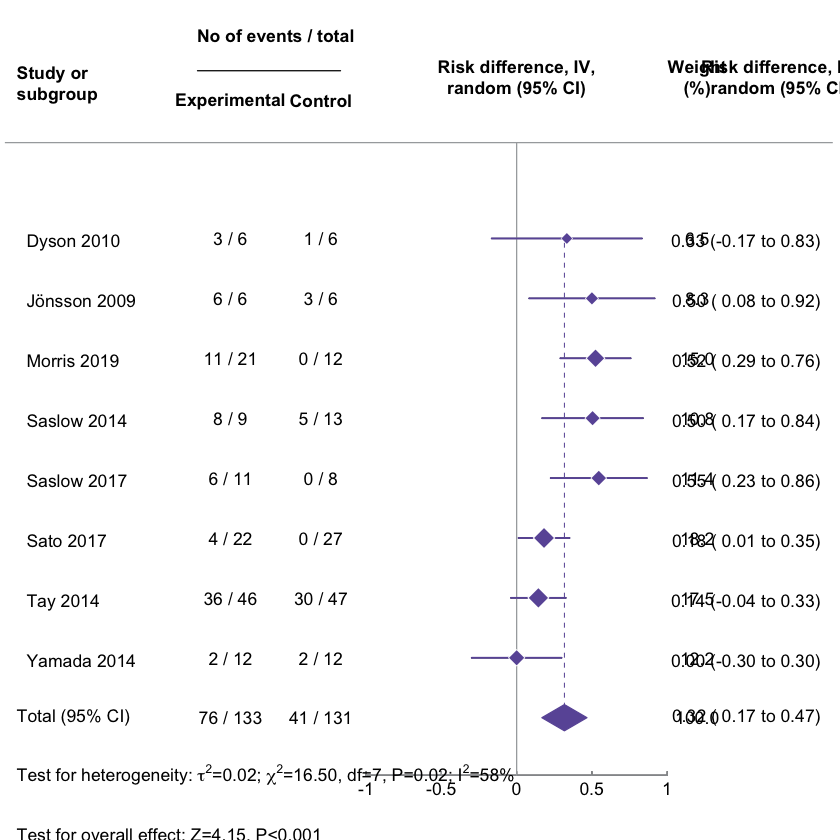

In [ ]:
### create dataset (from Goldenberg et al., 2021; http://dx.doi.org/10.1136/bmj.m4743)
dat <- data.frame(author = c("Dyson", "Jönsson", "Morris", "Saslow", "Saslow", "Sato", "Tay", "Yamada"),
                  year   = c(2010, 2009, 2019, 2014, 2017, 2017, 2014, 2014),
                  ai     = c(3, 6, 11, 8, 6, 4, 36, 2),
                  n1i    = c(6, 6, 21, 9, 11, 22, 46, 12),
                  ci     = c(1, 3, 0, 5, 0, 0, 30, 2),
                  n2i    = c(6, 6, 12, 13, 8, 27, 47, 12))
 
### calculate risk differences and corresponding sampling variances (and use
### the 'slab' argument to store study labels as part of the data frame)
dat <- escalc(measure="RD", ai=ai, n1i=n1i, ci=ci, n2i=n2i, data=dat,
              slab=paste(" ", author, year), addyi=FALSE)
dat
 
### fit random-effects model (using DL estimator as RevMan does)
res <- rma(yi, vi, data=dat, method="DL")
res
 
############################################################################
 
### colors to be used in the plot
colp <- "#6b58a6"
coll <- "#a7a9ac"
 
### total number of studies
k <- nrow(dat)
 
### generate point sizes
psize <- weights(res)
psize <- 1.2 + (psize - min(psize)) / (max(psize) - min(psize))
 
### get the weights and format them as will be used in the forest plot
weights <- formatC(weights(res), format="f", digits=1)
 
### adjust the margins
par(mar=c(2.7,3.2,2.3,1.3), mgp=c(3,0,0), tcl=0.15)
 
### forest plot with extra annotations
sav <- forest(dat$yi, dat$vi, xlim=c(-3.4,2.1), ylim=c(-0.5,k+3), alim=c(-1,1), cex=0.88,
              pch=18, psize=psize, efac=0, refline=NA, lty=c(1,0), xlab="",
              ilab=cbind(paste(dat$ai, "/", dat$n1i), paste(dat$ci, "/", dat$n2i), weights),
              ilab.xpos=c(-1.9,-1.3,1.2), annosym=c(" (", " to ", ")"),
              rowadj=-.07)
 
### add vertical reference line at 0
segments(0, -1, 0, k+1.6, col=coll)
 
### add vertical reference line at the pooled estimate
segments(coef(res), 0, coef(res), k, col=colp, lty="33", lwd=0.8)
 
### redraw the CI lines and points in the chosen color
segments(summary(dat)$ci.lb, k:1, summary(dat)$ci.ub, k:1, col=colp, lwd=1.5)
points(dat$yi, k:1, pch=18, cex=psize*1.15, col="white")
points(dat$yi, k:1, pch=18, cex=psize, col=colp)
 
### add the summary polygon
addpoly(res, row=0, mlab="Total (95% CI)", efac=2, col=colp, border=colp)
 
### add horizontal line at the top
abline(h=k+1.6, col=coll)
 
### redraw the x-axis in the chosen color
axis(side=1, at=seq(-1,1,by=0.5), col=coll, labels=FALSE)
 
### now we add a bunch of text; since some of the text falls outside of the
### plot region, we set xpd=NA so nothing gets clipped
par(xpd=NA)
 
### adjust cex as used in the forest plot and use a bold font
par(cex=sav$cex, font=2)
 
### add headings
text(sav$xlim[1], k+2.5, pos=4, "Study or\nsubgroup")
text(sav$ilab.xpos[1:2], k+2.3, c("Experimental","Control"))
text(mean(sav$ilab.xpos[1:2]), k+3.4, "No of events / total")
text(0, k+2.7, "Risk difference, IV,\nrandom (95% CI)")
segments(sav$ilab.xpos[1]-0.22, k+2.8, sav$ilab.xpos[2]+0.13, k+2.8)
text(c(sav$ilab.xpos[3],sav$xlim[2]-0.35), k+2.7, c("Weight\n(%)","Risk difference, IV,\nrandom (95% CI)"))
 
### add 'Favours caffeine'/'Favours decaf' text below the x-axis
text(c(-1,1), -2.5, c("Favors control","Favors experimental"), pos=c(4,2), offset=-0.3)
 
### use a non-bold font for the rest of the text
par(cex=sav$cex, font=1)
 
### add the 100.0 for the sum of the weights
text(sav$ilab.xpos[3], 0, "100.0")
 
### add the column totals for the counts and sample sizes
text(sav$ilab.xpos[1:2], 0, c(paste(sum(dat$ai), "/", sum(dat$n1i)), paste(sum(dat$ci), "/", sum(dat$n2i))))
 
### add text with heterogeneity statistics
text(sav$xlim[1], -1, pos=4, bquote(paste("Test for heterogeneity: ", tau^2, "=",
     .(formatC(res$tau2, digits=2, format="f")), "; ", chi^2, "=",
     .(formatC(res$QE, digits=2, format="f")), ", df=", .(res$k - res$p),
     ", P=", .(formatC(res$QEp, digits=2, format="f")), "; ", I^2, "=",
     .(formatC(res$I2, digits=0, format="f")), "%")))
 
### add text for test of overall effect
text(sav$xlim[1], -2, pos=4, bquote(paste("Test for overall effect: Z=",
     .(formatC(res$zval, digits=2, format="f")),
     ", P", .(ifelse(res$pval<.001, "<0.001",
                     paste0("=",formatC(res$pval, digits=2, format="f")))))))

In [ ]:
### fit random-effects model
res <- rma(yi, vi, data=dat.hackshaw1998)
 
### funnel plot centered at 0
funnel(res, refline=0)
 
### regression test (by default using the standard error as predictor)
reg <- regtest(res)
 
### add regression line to funnel plot
se <- seq(0,0.8,length=100)
lines(coef(reg$fit)[1] + coef(reg$fit)[2]*se, se)
 
### regression test (using the sampling variance as predictor)
reg <- regtest(res, predictor="vi")
 
### add regression line to funnel plot (using the sampling variance as predictor)
lines(coef(reg$fit)[1] + coef(reg$fit)[2]*se^2, se, lwd=2, lty="dotted")
 
### add legend
legend("topright", inset=.02, lty=c("solid","dotted"), lwd=2, cex=0.9, bg="white",
       legend=c("Standard Errors as Predictor",
                "Sampling Variances as Predictor"))